# Target Regions for a Parkinson’s Disease Virtual Gene Panel


## Overview


1.  Query panels in `PanelApp API`.
2.  Clean, merge, and filter GREEN (diagnostic quality) entities.
3.  Query GREEN gene data in `NCBI Datasets API`.
4.  Clean recovered gene data.
5.  Enrich Panel with RefSeq annotations.
6.  Create BED file with exons, STRs, CNVs.


In [1]:
# Imports and setup

%load_ext autoreload
%autoreload 2

import logging
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib_venn import venn2 #TODO: add this package to requirements.txt


logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
project_root = Path().resolve().parent
sys.path.append(str(project_root))
from src import *

## Retrieve & Structure Panels


In [2]:
# Query PanelApp APIs

panelapp_queries: list[PanelAppPanelId] = [
    # Parkinson Disease and Complex Parkinsonism (Version 1.127), Genomics England PanelApp
    PanelAppPanelId(
        healthcare_system=PanelAppHealthSystem.ENGLAND, id="39", version="1.127"
    ),
    # Early-onset Parkinson disease (Version 2.36), PanelApp Australia
    PanelAppPanelId(
        healthcare_system=PanelAppHealthSystem.AUSTRALIA, id="26", version="2.36"
    ),
]

results: dict[str, Any] = dict()
for query in panelapp_queries:
    logging.info(f"Querying {query}...")
    response = PanelAppClient(query.healthcare_system).get_single_panel(query)
    results[f"{query}"] = response
    logging.info("Done!\n")

INFO: Querying PA-ENGLAND_39_v1.127...
INFO: HTTP Request: GET https://panelapp.genomicsengland.co.uk/api/v1/panels/39/?version=1.127 "HTTP/1.1 200 OK"
INFO: Done!

INFO: Querying PA-AUSTRALIA_26_v2.36...
INFO: HTTP Request: GET https://panelapp-aus.org/api/v1/panels/26/?version=2.36 "HTTP/1.1 200 OK"
INFO: Done!



In [3]:
# Structure PanelApp API response and prepare for further cleaning

panelapp_panels: dict[str, PanelAppPanel] = dict()
for query, raw_panel in results.items():
    logging.info(f"Parsing response for {query}...")
    panelapp_panels[query] = PanelAppPanel.from_raw_panel(raw_panel)
    logging.info(f"Done!\n")

INFO: Parsing response for PA-ENGLAND_39_v1.127...
INFO: Done!

INFO: Parsing response for PA-AUSTRALIA_26_v2.36...
INFO: Done!



In [4]:
# Check Panels' Metadata and entities' status

for query, panel in panelapp_panels.items():
    print(f"{query}\n{panel.metadata}", flush=True)
    display(pd.crosstab(panel.df["Type"], panel.df["Status"], margins=True))

PA-ENGLAND_39_v1.127
Parkinson Disease and Complex Parkinsonism (v1.127, 2025-03-13).
	Relevant disorders:
	- Complex Parkinsonism (includes pallido-pyramidal syndromes).
	- Early onset and familial Parkinson's Disease.


Status,GREEN,AMBER,RED,GRAY,All
Type,,,,,
GENE,36,4,20,12,72
STR,9,0,0,0,9
All,45,4,20,12,81


PA-AUSTRALIA_26_v2.36
Early-onset Parkinson disease (v2.36, 2025-06-10).
	Relevant disorders:
	- Abnormality of extrapyramidal motor function.
	- HP:0002071.


Status,GREEN,AMBER,RED,GRAY,All
Type,,,,,
GENE,88,12,15,11,126
STR,14,0,0,0,14
All,102,12,15,11,140


## Consensus Panels' GREEN (Diagnostic Quality) Entities


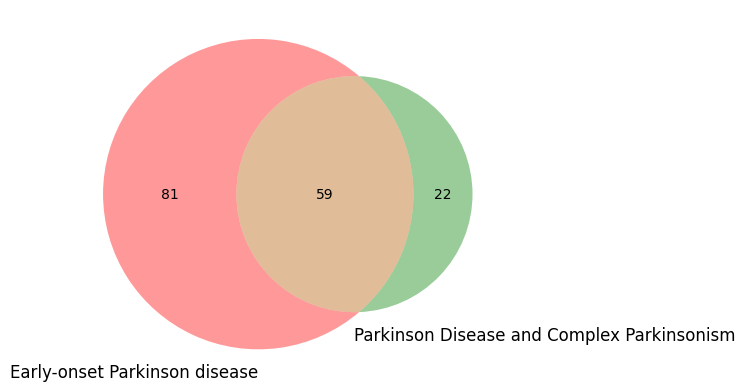

In [5]:
# Pair to merge
keys_to_merge = ("PA-AUSTRALIA_26_v2.36", "PA-ENGLAND_39_v1.127")
suffixes_map = {"PA-AUSTRALIA_26_v2.36": "_AUS", "PA-ENGLAND_39_v1.127": "_UK"}

# Visual characteristics

venn2(
    (
        set(panelapp_panels[keys_to_merge[0]].df["Name"]),
        set(panelapp_panels[keys_to_merge[1]].df["Name"]),
    ),
    (
        panelapp_panels[keys_to_merge[0]].metadata.name,
        panelapp_panels[keys_to_merge[1]].metadata.name,
    ),
)

In [6]:
# Merge and filter GREEN entities

panelapp_merged = PanelAppMerged.new(
    panelapp_panels[keys_to_merge[0]],
    panelapp_panels[keys_to_merge[1]],
    keys_to_merge[0],
    keys_to_merge[1],
    suffixes_map[keys_to_merge[0]],
    suffixes_map[keys_to_merge[1]],
)

panelapp_merged.df["_merge"].value_counts(dropna=False)

INFO: FIND CONFLICTS START.
INFO: Checking conflicts for Type...
INFO: NOT found conflicts.
INFO: Checking conflicts for Status...
INFO: Checking conflicts for GRCh38_chr...
INFO: NOT found conflicts.
INFO: Checking conflicts for GRCh38_start...
INFO: NOT found conflicts.
INFO: Checking conflicts for GRCh38_end...
INFO: NOT found conflicts.
INFO: Checking conflicts for HGNC_ID...
INFO: NOT found conflicts.
INFO: Checking conflicts for HGNC_symbol...
INFO: NOT found conflicts.
INFO: Columns with conflicts: (1) ['Status']
INFO: FIND CONFLICTS END.


_merge
left_only     54
both          50
right_only     9
Name: count, dtype: int64

In [7]:
# List conflicts that may require manual resolution

for col_name, conflict in panelapp_merged.conflicts.items():
    print(f"Conflict details for column {col_name}:", flush=True)

    conflict_col1 = f"{col_name}{panelapp_merged.suffix_left}"
    conflict_col2 = f"{col_name}{panelapp_merged.suffix_right}"

    display(
        pd.crosstab(
            conflict[conflict_col1],
            conflict[conflict_col2],
            margins=True,
        )
    )

    display(
        conflict[
            [
                conflict_col1,
                conflict_col2,
            ]
        ]
    )

Conflict details for column Status:


Status_UK,GREEN,AMBER,RED,GRAY,All
Status_AUS,,,,,
GREEN,0,1,2,11,14
RED,2,0,0,0,2
All,2,1,2,11,16


,Status_AUS,Status_UK
10,GREEN,RED
11,GREEN,GRAY
28,GREEN,AMBER
29,GREEN,GRAY
31,GREEN,GRAY
38,GREEN,GRAY
40,GREEN,GRAY
80,GREEN,RED
82,RED,GREEN
85,GREEN,GRAY


In [ ]:
# TODO: Explain complexities of panel harmonization
# TODO: Since Status conflict is expected for most of the cases, may be worth to add this as a default solving strategy

conflicted_field = "Status"
consensus_col_name = f"{conflicted_field}_Consensus"

panelapp_merged.df[consensus_col_name] = panelapp_merged.df.apply(
    lambda row, col_name_left, col_name_right: (
        "GREEN"
        if row[col_name_left]
        == row[col_name_right]
        else "MIXED"
    ), args = [f"{conflicted_field}{panelapp_merged.suffix_left}", f"{conflicted_field}{panelapp_merged.suffix_right}"]
    axis=1,
)

panelapp_merged.df[consensus_col_name] = panelapp_merged.df[consensus_col_name].astype(
    "category"
)

panelapp_merged.df[consensus_col_name].value_counts(dropna=False)

Status_Consensus
MIXED    79
GREEN    34
Name: count, dtype: int64

INFO: MAKE CONSENSUS START.
INFO: Copying unconflicted...
INFO: Creating new DataFrame...
INFO: MAKE CONSENSUS END.


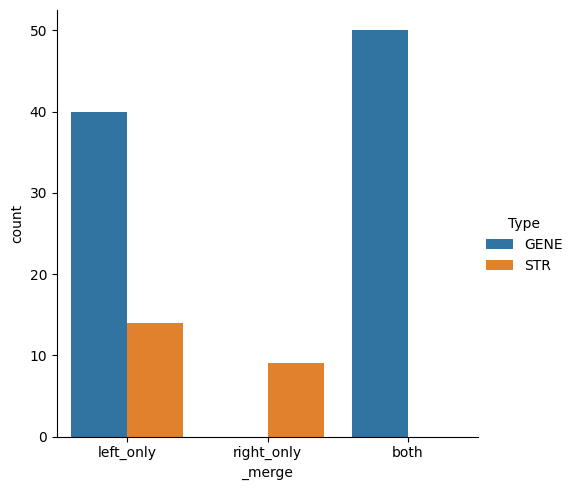

In [9]:
# Build consensus DataFrame

consensus_panel_df = panelapp_merged.make_consensus(custom_include=["Status_Consensus"])

sns.catplot(data=panelapp_merged.df, x="_merge", hue="Type", kind="count")

In [10]:
pd.crosstab(
    consensus_panel_df["Status_Consensus"],
    consensus_panel_df["Type"],
    margins=True,
)

Type,GENE,STR,All
Status_Consensus,,,
GREEN,34,0,34
MIXED,56,23,79
All,90,23,113


<Axes: xlabel='GRCh38_chr', ylabel='count'>

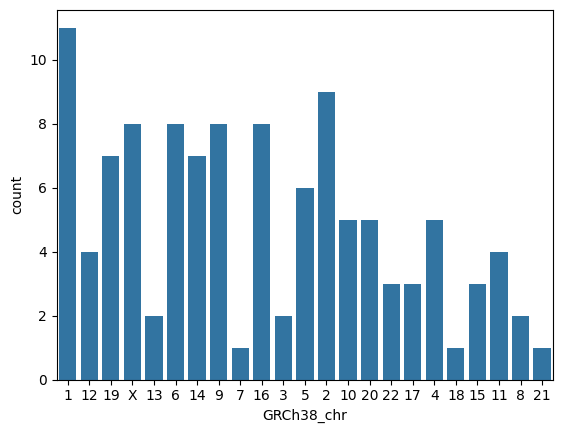

In [ ]:
# TODO: make chromosome categorical and ordered, include MT and Unplaced
sns.countplot(data=consensus_panel_df, x="GRCh38_chr")

## Retrieve & Parse Gene RefSeq Annotations


Next steps...

- Replace Ensembl 90/10X gene annotations by RefSeq
- Create BED with GENE entities exons, STRs, and CNVs regions.
- Analysis and conclusions
